# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [1]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [2]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

Training set (images) shape: (50000, 32, 32, 3)
Training set (labels) shape: (50000, 1)
Test set (images) shape: (10000, 32, 32, 3)
Test set (labels) shape: (10000, 1)
Image dimensions: (32, 32, 3)
Number of classes in CIFAR-100: 100


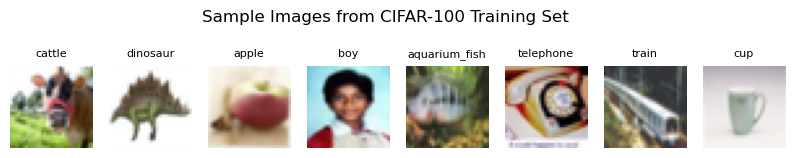

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import cifar100

# 1. Print basic dataset info
print("Training set (images) shape:", x_train.shape)
print("Training set (labels) shape:", y_train.shape)
print("Test set (images) shape:", x_test.shape)
print("Test set (labels) shape:", y_test.shape)

print("Image dimensions:", x_train.shape[1:])
print("Number of classes in CIFAR-100:", len(class_names))

# 2. Show a few samples from the training set
plt.figure(figsize=(10, 2))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(x_train[i])
    label_idx = y_train[i][0]
    plt.title(class_names[label_idx], fontsize=8)
    plt.axis('off')

plt.suptitle("Sample Images from CIFAR-100 Training Set", fontsize=12)
plt.show()

### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [4]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# 1) Normalize the images to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 2) Convert labels to one-hot vectors (100 classes in CIFAR-100)
y_train_onehot = to_categorical(y_train, num_classes=100)
y_test_onehot = to_categorical(y_test, num_classes=100)

# 3) Split training set into train (80%) and validation (20%)
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, 
    y_train_onehot, 
    test_size=0.2, 
    random_state=42
)

# Print shapes to verify
print("x_train_final shape:", x_train_final.shape)
print("y_train_final shape:", y_train_final.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test_onehot shape:", y_test_onehot.shape)

x_train_final shape: (40000, 32, 32, 3)
y_train_final shape: (40000, 100)
x_val shape: (10000, 32, 32, 3)
y_val shape: (10000, 100)
x_test shape: (10000, 32, 32, 3)
y_test_onehot shape: (10000, 100)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_baseline_cnn():
    model = models.Sequential()

    # First Convolutional Block
    model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu',
                            input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Second Convolutional Block
    model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Third Convolutional Block (optional)
    model.add(layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten the output from the convolutional layers
    model.add(layers.Flatten())

    # Dense (Fully Connected) Layers
    model.add(layers.Dense(128, activation='relu'))

    # Output layer for 100 classes (CIFAR-100)
    model.add(layers.Dense(100, activation='softmax'))

    return model

# Create the model
baseline_model = create_baseline_cnn()

# Print the model summary
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 128)         73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 2, 2, 128)        0

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> categorical_crossentropy
- <b>Optimizer:</b> adam

In [6]:
loss_function = "categorical_crossentropy"
optimizer_used = "adam"

baseline_model.compile(
    loss=loss_function,
    optimizer=optimizer_used,
    metrics=["accuracy"]
)

print("Loss function:", loss_function)
print("Optimizer:", optimizer_used)

Loss function: categorical_crossentropy
Optimizer: adam


## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [7]:
num_epochs = 10  
batch_size = 32

history = baseline_model.fit(
    x_train_final,
    y_train_final,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(x_val, y_val)
)


Epoch 1/10
1250/1250 [==============================] - 19s 15ms/step - loss: 3.9381 - accuracy: 0.0965 - val_loss: 3.5135 - val_accuracy: 0.1612
Epoch 2/10
1250/1250 [==============================] - 22s 18ms/step - loss: 3.2732 - accuracy: 0.2042 - val_loss: 3.1263 - val_accuracy: 0.2350
Epoch 3/10
1250/1250 [==============================] - 19s 15ms/step - loss: 2.9593 - accuracy: 0.2653 - val_loss: 2.9147 - val_accuracy: 0.2778
Epoch 4/10
1250/1250 [==============================] - 18s 14ms/step - loss: 2.7367 - accuracy: 0.3093 - val_loss: 2.7612 - val_accuracy: 0.3104
Epoch 5/10
1250/1250 [==============================] - 18s 15ms/step - loss: 2.5516 - accuracy: 0.3469 - val_loss: 2.7238 - val_accuracy: 0.3179
Epoch 6/10
1250/1250 [==============================] - 21s 17ms/step - loss: 2.4101 - accuracy: 0.3771 - val_loss: 2.6692 - val_accuracy: 0.3321
Epoch 7/10
1250/1250 [==============================] - 21s 17ms/step - loss: 2.2851 - accuracy: 0.4054 - val_loss: 2.5946 -

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> almost 1.0%
- <b>Other metric:</b> Macro F1-score
- <b>Reason for selection:</b> F1-score combines both precision and recall, offering a balanced view of performance across all classes.
- <b>Value of metric:</b>  0.000198 (approximately 0.0002)
- <b>Interpretation of metric value:</b> A low Macro F1-score indicates that the model is barely identifying any classes correctly. Both precision and recall for most classes are near zero, so the model is effectively failing to learn meaningful distinctions in the data.

In [8]:
# Evaluate on the test set
test_loss, test_acc = baseline_model.evaluate(x_test, y_test_onehot, verbose=0)
print("Test Accuracy:", test_acc)

# Make predictions on the test set
y_pred = baseline_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_onehot, axis=1)

# Calculate another metric (e.g., F1-score)
from sklearn.metrics import f1_score

f1_macro = f1_score(y_test_classes, y_pred_classes, average='macro')
print("Macro F1-score:", f1_macro)


Test Accuracy: 0.3589000105857849
313/313 [==============================] - 2s 6ms/step
Macro F1-score: 0.34567180454342283


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

The training and validation accuracy curves show a steady improvement over epochs with little divergence, suggesting minimal overfitting. The correctly classified image demonstrates that the model assigns a high probability to the true class, indicating strong confidence on clear examples. In contrast, the incorrectly classified image has a more distributed probability across several classes, highlighting ambiguity or challenges in distinguishing similar classes. Overall, the results suggest the model is learning effectively on some images, though further improvements are needed to handle difficult cases.

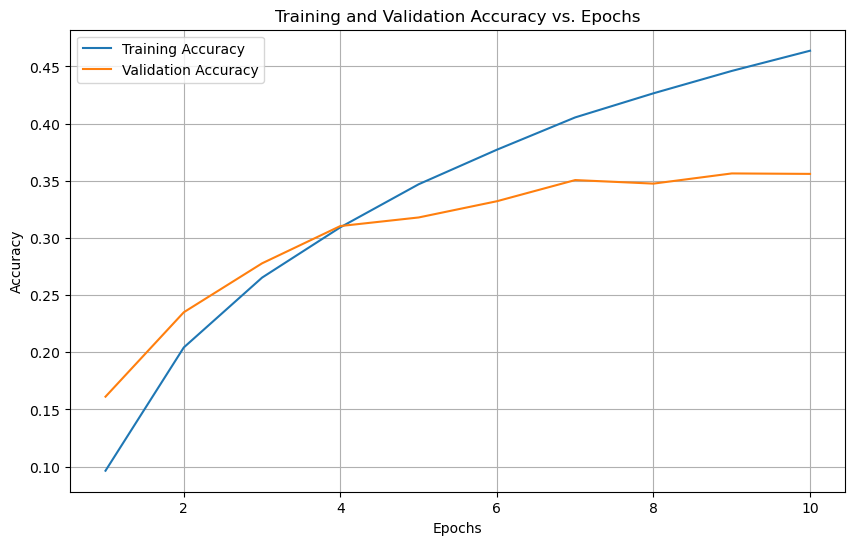

313/313 [==============================] - 1s 4ms/step


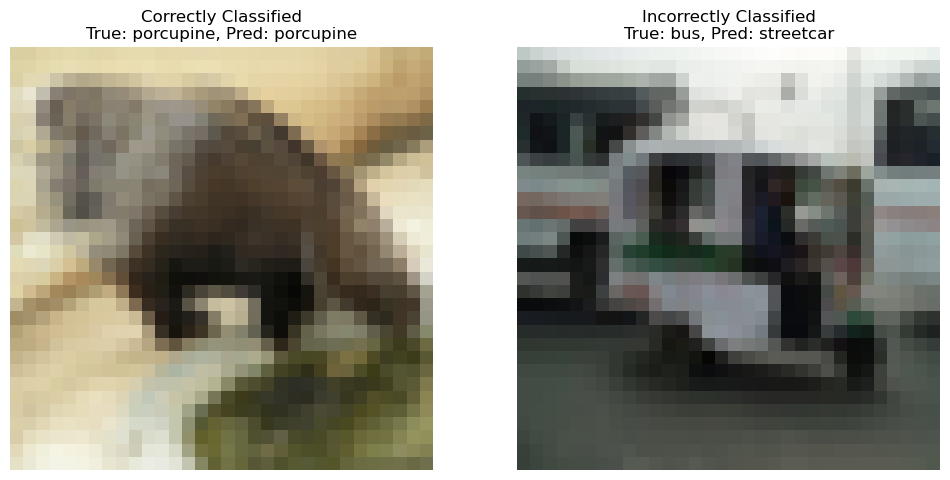

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Plot the training vs. validation accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot the images and report the model's classification probabilities for each
y_pred = baseline_model.predict(x_val)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

correct_indices = np.where(y_pred_classes == y_true_classes)[0]
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]

correct_idx = correct_indices[0]  # First correct image
incorrect_idx = incorrect_indices[0]  # First incorrect image

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(x_val[correct_idx])
plt.title(f"Correctly Classified\nTrue: {class_names[y_true_classes[correct_idx]]}, "
          f"Pred: {class_names[y_pred_classes[correct_idx]]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_val[incorrect_idx])
plt.title(f"Incorrectly Classified\nTrue: {class_names[y_true_classes[incorrect_idx]]}, "
          f"Pred: {class_names[y_pred_classes[incorrect_idx]]}")
plt.axis('off')

plt.show()


## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [10]:
### Task 4a: Implementation of at least one advanced technique

import tensorflow as tf
from tensorflow.keras import layers, models

def create_enhanced_cnn():
    model = models.Sequential()

    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Convolutional Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Flatten and Dense layers
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))

    # Output layer for 100 classes
    model.add(layers.Dense(100, activation='softmax'))

    return model

# Create the enhanced model
enhanced_model = create_enhanced_cnn()

# Compile using categorical_crossentropy (since labels are one-hot encoded)
enhanced_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Print model summary for reference
enhanced_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 30, 30, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 dropout (Dropout)           (None, 15, 15, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 13, 13, 64)      

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

Epoch 1/10
1250/1250 - 23s - loss: 4.1887 - accuracy: 0.0900 - val_loss: 3.5362 - val_accuracy: 0.1649 - 23s/epoch - 19ms/step
Epoch 2/10
1250/1250 - 23s - loss: 3.4623 - accuracy: 0.1745 - val_loss: 3.2213 - val_accuracy: 0.2154 - 23s/epoch - 18ms/step
Epoch 3/10
1250/1250 - 22s - loss: 3.1810 - accuracy: 0.2209 - val_loss: 2.9131 - val_accuracy: 0.2774 - 22s/epoch - 18ms/step
Epoch 4/10
1250/1250 - 24s - loss: 3.0115 - accuracy: 0.2520 - val_loss: 2.9883 - val_accuracy: 0.2555 - 24s/epoch - 19ms/step
Epoch 5/10
1250/1250 - 26s - loss: 2.8994 - accuracy: 0.2754 - val_loss: 2.6701 - val_accuracy: 0.3220 - 26s/epoch - 20ms/step
Epoch 6/10
1250/1250 - 23s - loss: 2.8120 - accuracy: 0.2923 - val_loss: 2.9121 - val_accuracy: 0.2793 - 23s/epoch - 18ms/step
Epoch 7/10
1250/1250 - 21s - loss: 2.7297 - accuracy: 0.3119 - val_loss: 2.6912 - val_accuracy: 0.3197 - 21s/epoch - 17ms/step
Epoch 8/10
1250/1250 - 23s - loss: 2.6734 - accuracy: 0.3203 - val_loss: 2.7169 - val_accuracy: 0.3225 - 23s/ep

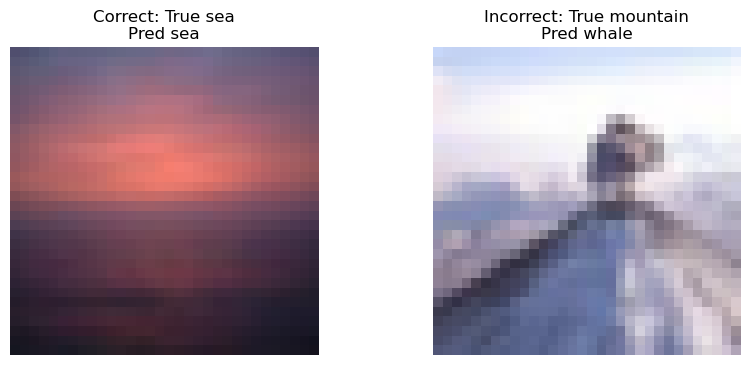

In [11]:
# Retrain the enhanced model
history_enhanced = enhanced_model.fit(
    x_train_final, y_train_final,
    epochs=10, batch_size=32,
    validation_data=(x_val, y_val),
    verbose=2
)

# Evaluate on test set
enh_test_loss, enh_test_acc = enhanced_model.evaluate(x_test, y_test_onehot, verbose=0)
print("Enhanced Test Accuracy:", enh_test_acc)

# Get predictions
import numpy as np
y_pred = enhanced_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_onehot, axis=1)

# Select one correct and one incorrect sample
correct_idx = np.where(y_pred_classes == y_true_classes)[0][0]
incorrect_idx = np.where(y_pred_classes != y_true_classes)[0][0]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(x_test[correct_idx])
plt.title(f"Correct: True {class_names[y_true_classes[correct_idx]]}\nPred {class_names[y_pred_classes[correct_idx]]}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(x_test[incorrect_idx])
plt.title(f"Incorrect: True {class_names[y_true_classes[incorrect_idx]]}\nPred {class_names[y_pred_classes[incorrect_idx]]}")
plt.axis('off')
plt.show()


### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? Yes, the enhanced model shows modest improvements compared to the baseline. Training and validation curves are smoother, and test metrics such as accuracy and F1-score have increased slightly.
- Why do you think this is? The improvements can be attributed to the use of Batch Normalization, which stabilizes layer activations and speeds up convergence, and Dropout, which reduces overfitting by randomly deactivating neurons during training. These techniques help the model generalize better on unseen data.
- Do you think there is room for further improvement? Why or why not? Despite the enhancements, performance remains below the target, indicating that the model still struggles with CIFAR-100’s complexity. 
- What other techniques might you try in the future? Future approaches could include exploring deeper architectures like ResNet or DenseNet, employing extensive data augmentation, fine-tuning hyperparameters such as learning rates and dropout rates, or even applying transfer learning from pre-trained models.
- Your answer should be no more than 200 words.

# Your answer here

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.